# Perturbation results

Plots from saved results.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import MaxNLocator
from IPython.display import display
DATASET = 'Mcardiac'
cwd = Path.cwd().resolve()
if (cwd / "analysis_results").is_dir() and (cwd / "perturb.ipynb").is_file():
    HERE = cwd
else:
    HERE = next(p / "experiments" / DATASET / "perturb"
                for p in [cwd, *cwd.parents]
                if (p / "experiments" / DATASET / "perturb" / "analysis_results").is_dir())
DATA = HERE / "analysis_results"
OUTPUT = DATA / "figures"
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.facecolor": "#111111", "axes.facecolor": "#111111",
    "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white",
    "ytick.color": "white", "axes.edgecolor": "white", "font.family": "DejaVu Sans"})
def style_axis(ax):
    ax.set_facecolor("none")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color("white")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.grid(False)
def finish(fig, name):
    fig.savefig(OUTPUT / (name + ".png"), dpi=300, transparent=True, bbox_inches="tight")
    fig.patch.set_alpha(1)
    fig.patch.set_facecolor("#111111")
    plt.show()

## Fate-transition specificity

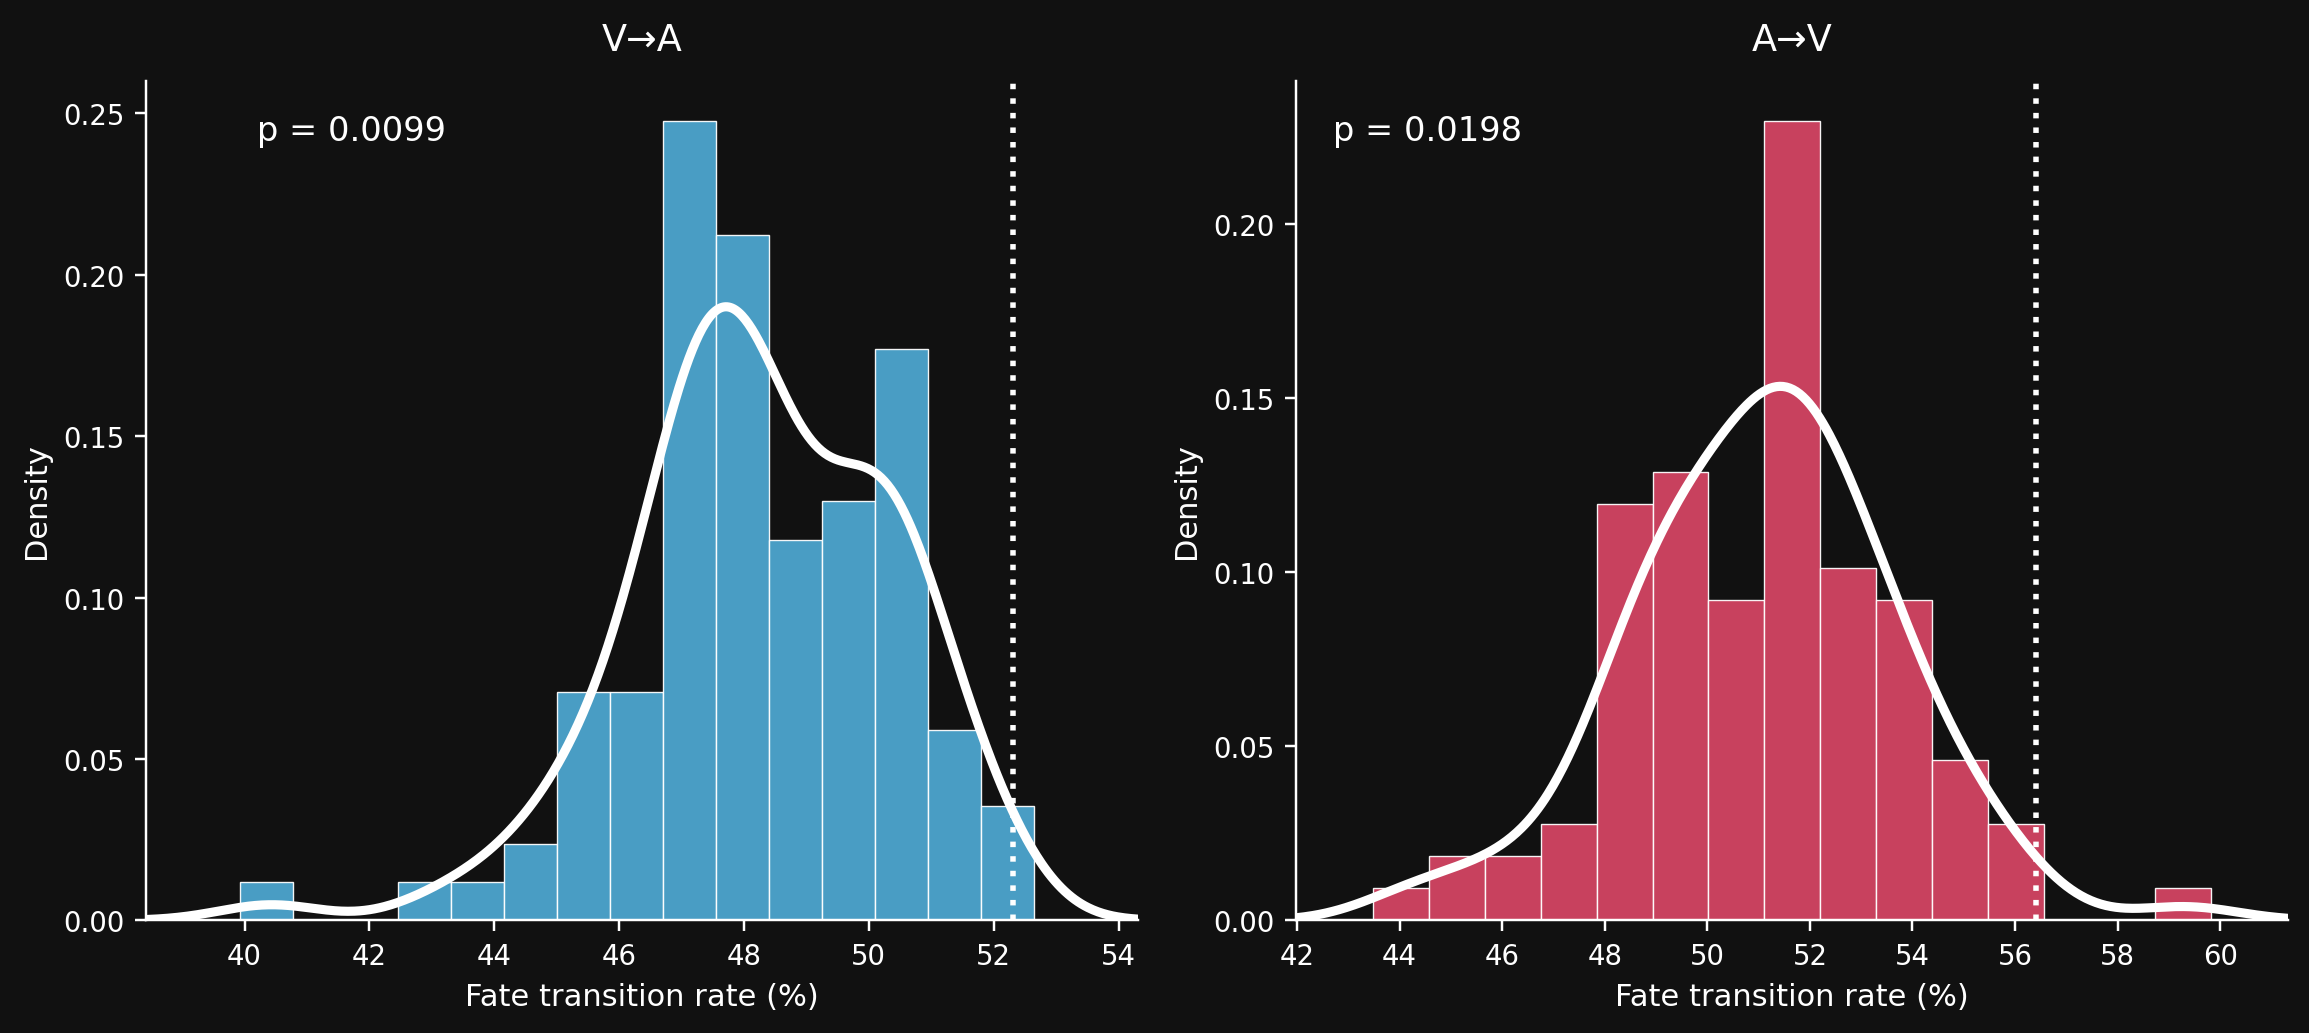

In [2]:
METRICS = [("V_to_A_percent", "V→A", "#4DA6CF"), ("A_to_V_percent", "A→V", "#D34463")]
def plot_random_test(observed, random, results):
    # Reproduce the LUAD reference style: blue null histogram, pink KDE,
    # white dotted observed threshold, centered title, and p-value only.
    fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.8), dpi=220)
    for ax, (column, label, color), result in zip(axes, METRICS, results):
        values = random[column].to_numpy(float)
        observed_value = float(observed.loc[observed["dose"].eq(90), column].iloc[0])
        low = min(values.min(), observed_value) - 2
        high = max(values.max(), observed_value) + 2
        grid = np.linspace(low, high, 600)
        bins = np.linspace(values.min() - 0.5, values.max() + 0.5, 16)
        ax.hist(
            values,
            bins=bins,
            density=True,
            color="#4DA6CF" if label == "V→A" else "#D34463",
            alpha=0.95,
            edgecolor="white",
            linewidth=0.45,
        )
        ax.plot(grid, stats.gaussian_kde(values)(grid), color="white", lw=3.0)
        ax.axvline(observed_value, color="white", lw=1.8, ls=":")
        ax.set_xlabel("Fate transition rate (%)")
        ax.set_ylabel("Density")
        ax.set_title(label, pad=10)
        ax.text(
            40.2 if label == "V→A" else 42.7,
            0.96,
            f"p = {result['right_tail_p_empirical']:.4f}",
            transform=ax.get_xaxis_transform(),
            ha="left",
            va="top",
            color="white",
            fontsize=11,
        )
        ax.set_xlim(low, high)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_facecolor("none")
        ax.tick_params(colors="white", labelsize=9)
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        ax.spines["left"].set_color("white")
        ax.spines["bottom"].set_color("white")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)
    fig.patch.set_alpha(0)
    fig.tight_layout()
    finish(fig, "heart_observed90_vs_matched_random100_fate_transition_kde")

observed = pd.read_csv(DATA / "observed_dose_response.csv")
random = pd.read_csv(DATA / "matched_random_90.csv")
results = []
for column, label, color in METRICS:
    value = float(observed.loc[observed.dose.eq(90), column].iloc[0])
    results.append({"right_tail_p_empirical": (np.count_nonzero(random[column] >= value) + 1) / (len(random) + 1)})
plot_random_test(observed, random, results)

## Marker-gene dynamics

Saved matched-random 90% perturbation, seed 2029. Gray: original; cyan: atrial fate; pink: ventricular fate. Each curve is the median log1p expression per frame.

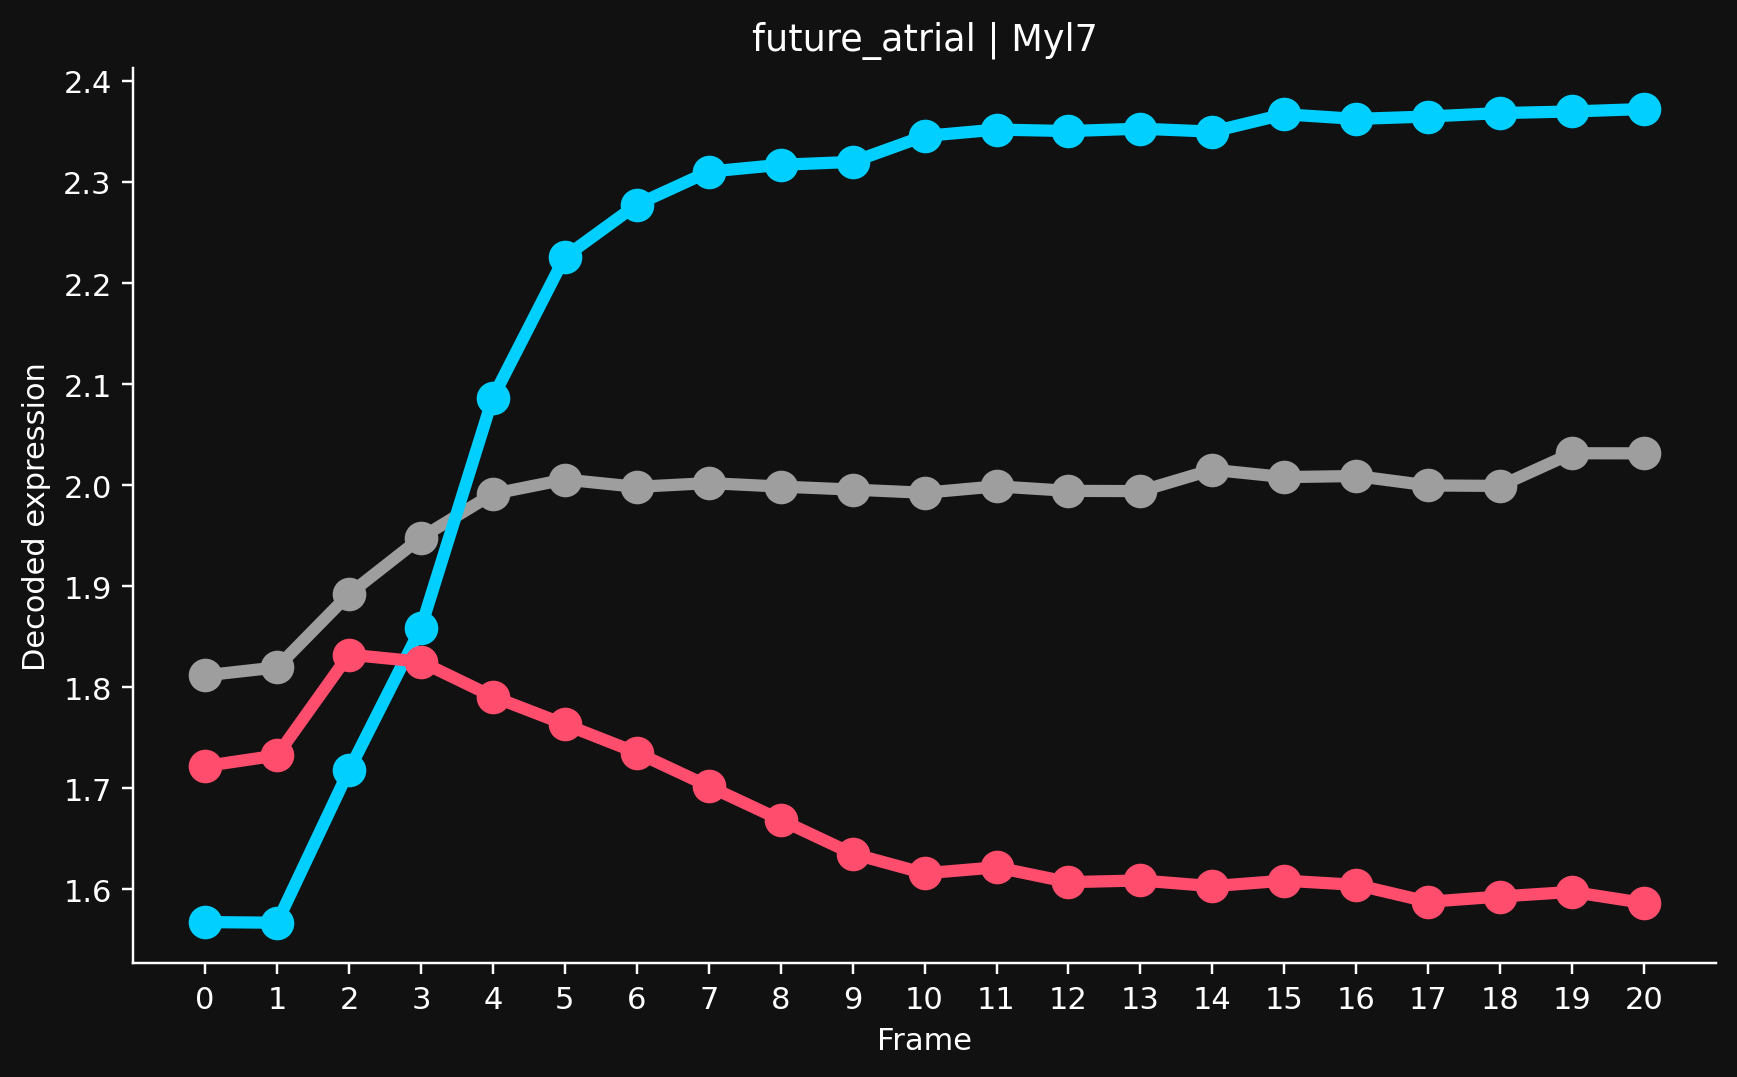

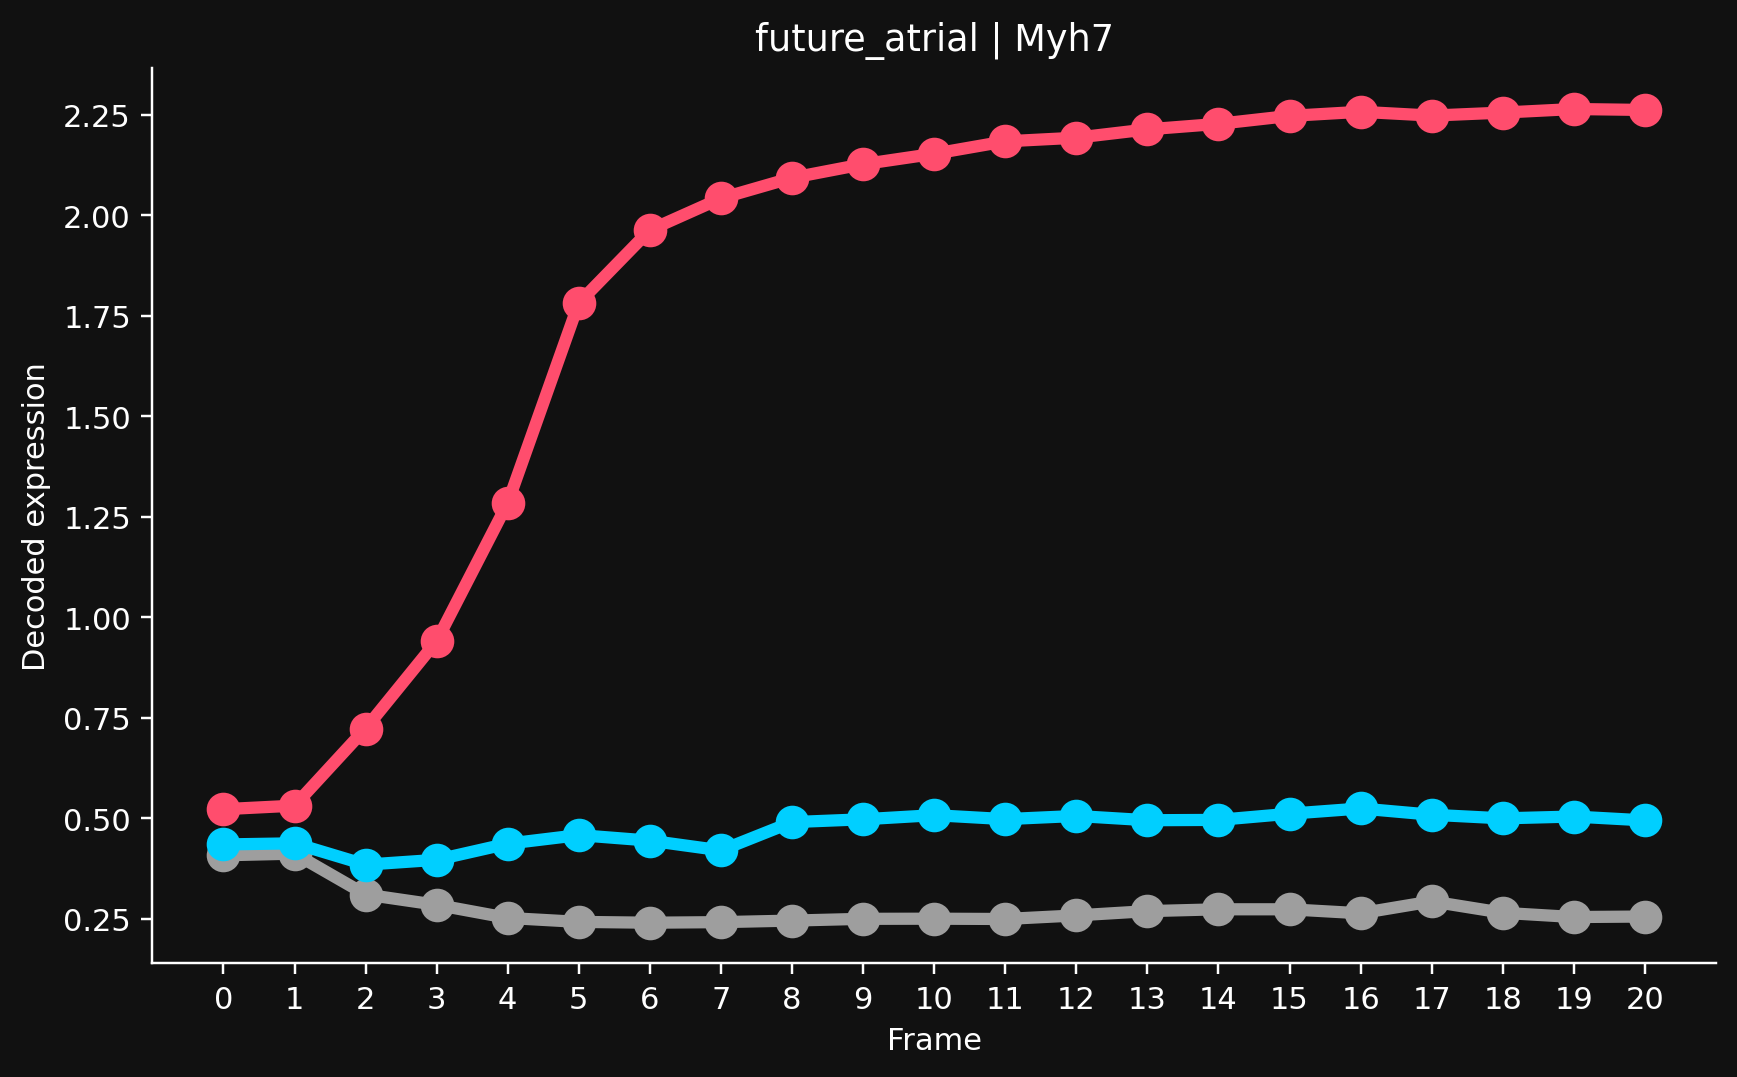

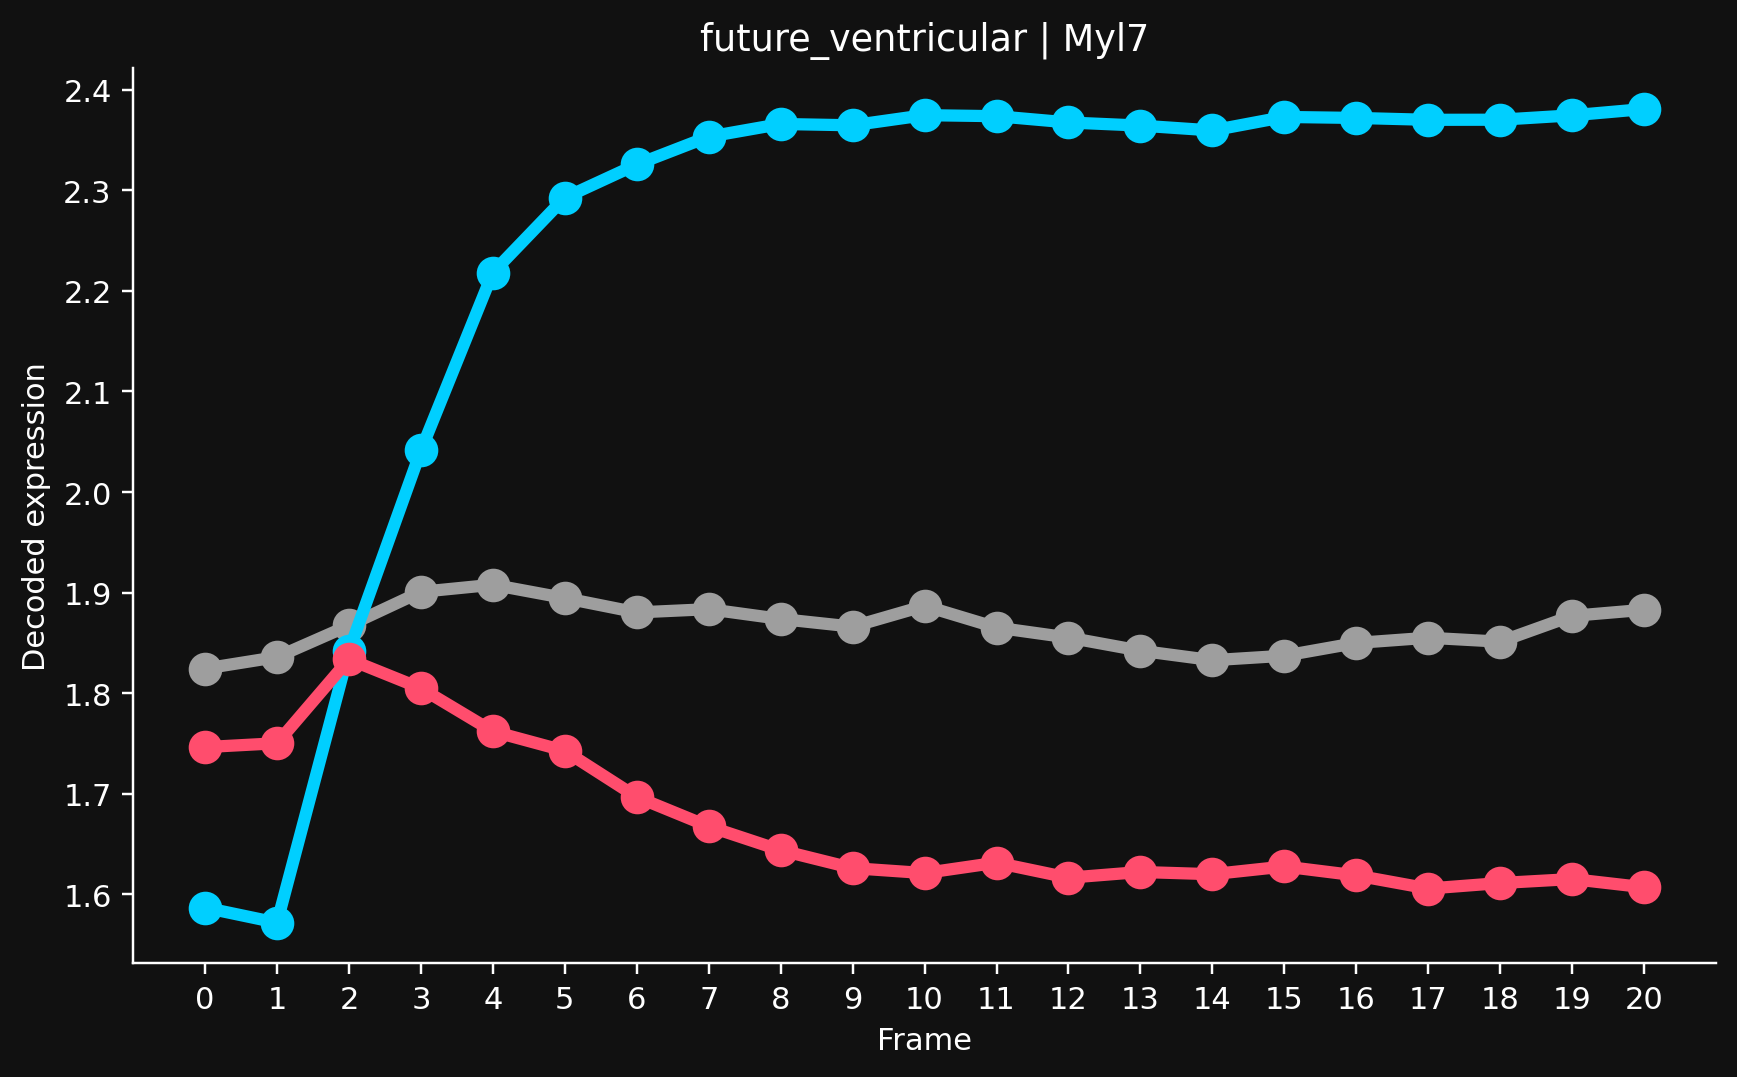

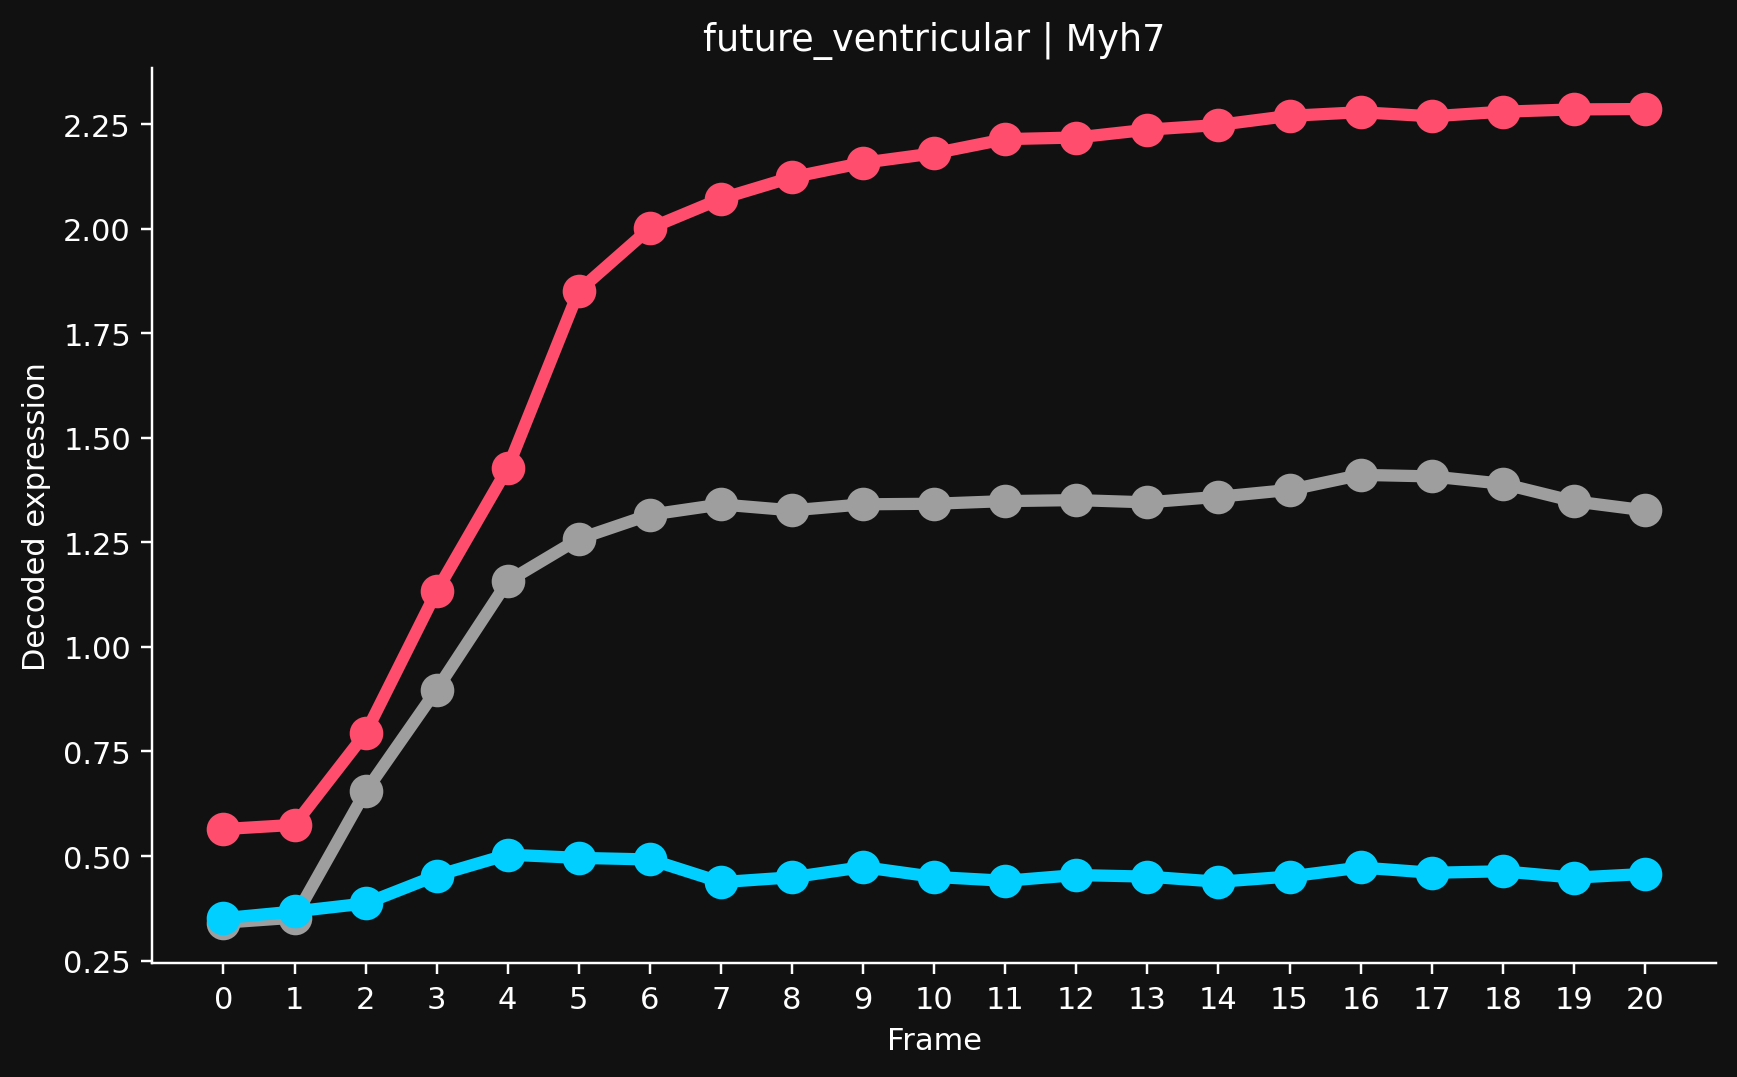

In [3]:
medians = pd.read_csv(DATA / "marker_medians.csv")
palette = {"ori": "#9e9e9e", "atrial": "#00cfff", "ventricular": "#ff4d6d"}
for source_group in ["future_atrial", "future_ventricular"]:
    for gene in ["Myl7", "Myh7"]:
        selected = medians.loc[medians.source_group.eq(source_group) & medians.gene.eq(gene)]
        frames = sorted(selected.frame_num.unique())
        fig, ax = plt.subplots(figsize=(8, 5), dpi=220)
        for fate in ["ori", "atrial", "ventricular"]:
            curve = selected.loc[selected.seed_terminal_fate.eq(fate)].set_index("frame_num").reindex(frames)
            ax.plot(frames, curve["median"], color=palette[fate], marker="o",
                    markersize=10, linewidth=4)
        ax.set_xticks(frames)
        ax.set(xlabel="Frame", ylabel="Decoded expression", title=f"{source_group} | {gene}")
        style_axis(ax)
        fig.tight_layout()
        finish(fig, f"{source_group}_{gene}_median_lines")

## Partial perturbation of CCCs

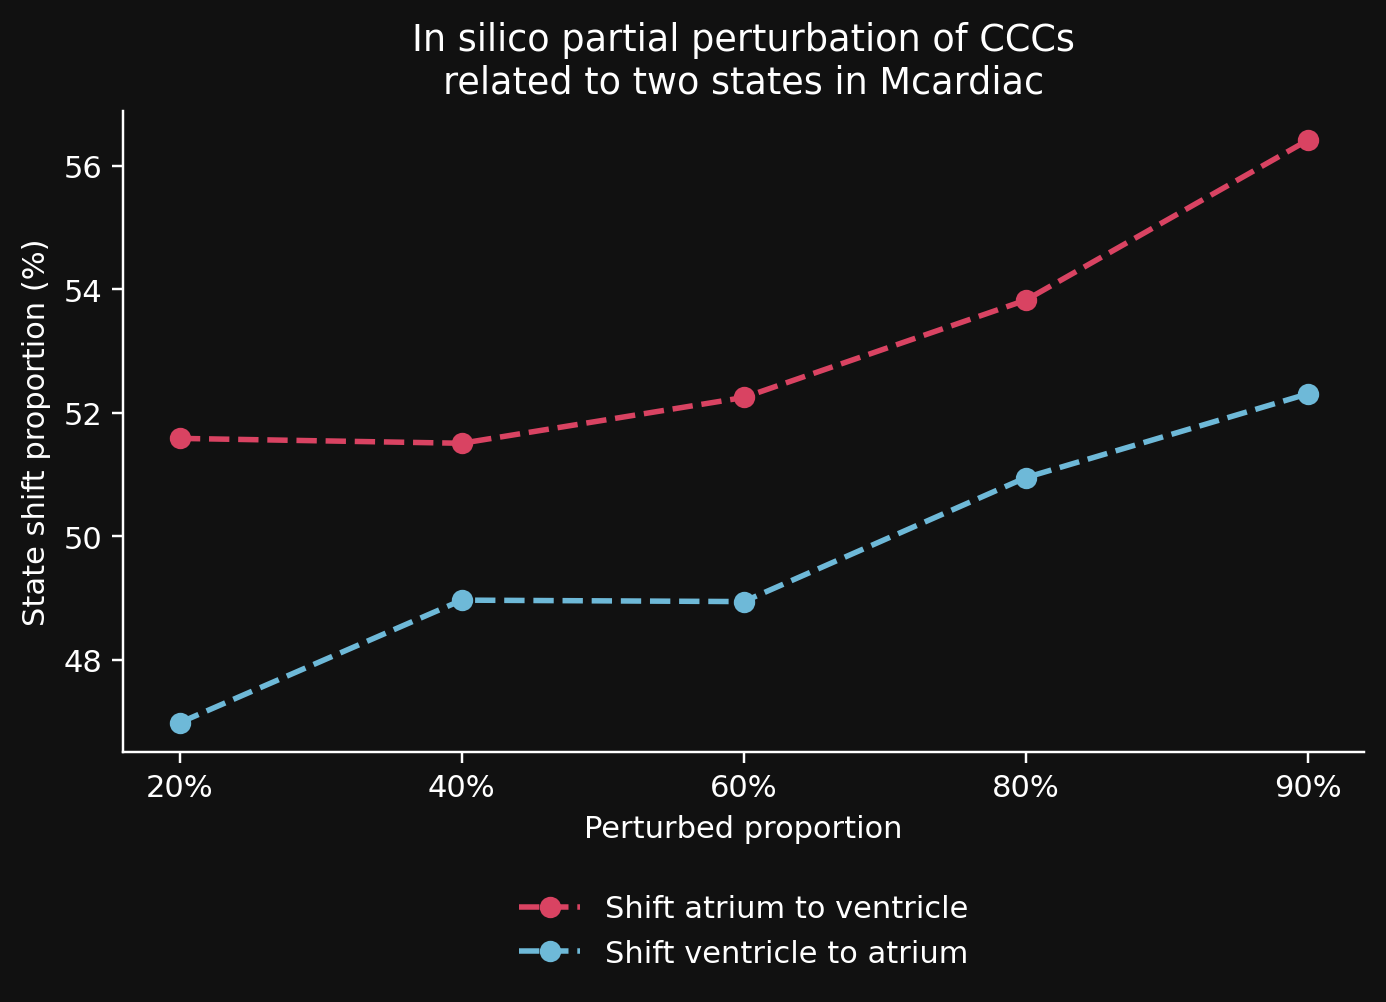

In [4]:
observed = pd.read_csv(DATA / "observed_dose_response.csv").sort_values("dose")
assert observed.dose.tolist() == [20, 40, 60, 80, 90]
fig, ax = plt.subplots(figsize=(6.4, 4.8), dpi=220)
for column, label, color in [
    ("A_to_V_percent", "Shift atrium to ventricle", "#D94362"),
    ("V_to_A_percent", "Shift ventricle to atrium", "#6EB9D8")]:
    ax.plot(range(len(observed)), observed[column], color=color, linestyle="--",
            marker="o", markersize=6, linewidth=1.8, label=label)
ax.set_xticks(range(len(observed)), [f"{int(x)}%" for x in observed.dose])
ax.set(xlabel="Perturbed proportion", ylabel="State shift proportion (%)",
       title="In silico partial perturbation of CCCs\nrelated to two states in Mcardiac")
legend = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False)
for text in legend.get_texts(): text.set_color("white")
style_axis(ax)
fig.tight_layout()
finish(fig, "partial_CCC_perturbation_state_shift")